In [1]:
RUTA_DATOS   = r"/Users/ykath/OneDrive - Universidad de los Andes/Escritorio/Instructora/20261/Grupos armados/Datos consolidados/BD_binarias3.csv"
RUTA_ARISTAS = r"C:\Users\ykath\Downloads\edges_geograficos.csv"

---
## Paso 0: reconstruir exactamente el mismo setup

In [2]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from torch_geometric.nn import GCNConv

torch.manual_seed(0)
np.random.seed(0)

df = pd.read_csv(RUTA_DATOS)
feature_cols = [c for c in df.columns if c not in ['codigo', 'DUQUE_win']]
X_raw = df[feature_cols].values.astype(np.float32)
y_raw = df['DUQUE_win'].values.astype(np.float32)
codigos = df['codigo'].values

x = torch.tensor(X_raw)
y = torch.tensor(y_raw)
n, p = x.shape
print(f"Municipios: {n}, variables: {p}")

# Red geográfica
edges_df = pd.read_csv(RUTA_ARISTAS)
codigo_to_idx = {c: i for i, c in enumerate(codigos)}
src = edges_df['municipio_origen'].map(codigo_to_idx).values
dst = edges_df['municipio_destino'].map(codigo_to_idx).values
edge_index = torch.tensor(
    np.vstack([np.concatenate([src, dst]), np.concatenate([dst, src])]),
    dtype=torch.long
)
print(f"Aristas (ambos sentidos): {edge_index.shape[1]}")

# Misma partición que el notebook principal
perm = torch.randperm(n)
n_train = int(0.8 * n)
train_idx, test_idx = perm[:n_train], perm[n_train:]

pos_weight = torch.tensor([
    (y[train_idx] == 0).sum().item() / (y[train_idx] == 1).sum().item()
])
print(f"pos_weight: {pos_weight.item():.3f}")

Municipios: 965, variables: 36
Aristas (ambos sentidos): 4974
pos_weight: 0.266


---
# Parte 1: regresión logística

## 1.1 Entrenar el modelo

Es el mismo modelo del notebook principal, sin cambios.

In [3]:
logit = LogisticRegression(max_iter=2000, class_weight='balanced')
logit.fit(X_raw[train_idx.numpy()], y_raw[train_idx.numpy()])
acc_logit = balanced_accuracy_score(y_raw[test_idx.numpy()], logit.predict(X_raw[test_idx.numpy()]))
print(f"Balanced accuracy - Logit: {acc_logit:.3f}")

Balanced accuracy - Logit: 0.787


## 1.2 La matemática detrás

El logit calcula, para cada municipio $i$, un índice lineal (el **log-odds**):

$$z_i = \beta_0 + \sum_{k=1}^{36} \beta_k \, x_{ik} \;=\; \beta_0 + \mathbf{x}_i^\top \boldsymbol\beta$$

y luego la probabilidad $P_i = \sigma(z_i) = 1/(1+e^{-z_i})$.

Derivando el log-odds respecto a la variable $k$ del **mismo** municipio:

$$\frac{\partial z_i}{\partial x_{ik}} = \beta_k$$

Es una constante: no depende de $i$ ni del valor de $\mathbf{x}_i$, porque $z_i$ es lineal en $\mathbf{x}_i$.

In [4]:
beta  = torch.tensor(logit.coef_.flatten(), dtype=torch.float64)   # (36,)
beta0 = torch.tensor(logit.intercept_[0],  dtype=torch.float64)    # escalar

def logit_torch(X):
    # z_i = beta0 + x_i^T beta, para todos los municipios a la vez
    return X @ beta + beta0

X64 = x.to(torch.float64)
z_torch   = logit_torch(X64).numpy()
z_sklearn = logit.decision_function(X_raw.astype(np.float64))
print(f"Máx. diferencia log-odds PyTorch vs sklearn: {np.abs(z_torch - z_sklearn).max():.2e}")

Máx. diferencia log-odds PyTorch vs sklearn: 1.78e-15


## 1.4 Primera derivada con autograd: el "truco de la suma"

La forma más directa de pedirle a PyTorch las derivadas:

1. Marcamos la matriz de entrada con `requires_grad_(True)`, para que PyTorch registre cómo cada salida depende de ella.
2. Calculamos los 965 log-odds $z_1,\dots,z_n$.
3. Sumamos y llamamos `backward()`. PyTorch calcula $\nabla_X \big(\sum_i z_i\big)$ y lo guarda en `X.grad`.

¿Por qué sirve sumar? La entrada $(j,k)$ del gradiente es

$$\frac{\partial}{\partial x_{jk}} \sum_i z_i = \sum_i \frac{\partial z_i}{\partial x_{jk}} = \frac{\partial z_j}{\partial x_{jk}} + \underbrace{\sum_{i \neq j} \frac{\partial z_i}{\partial x_{jk}}}_{=\,0 \text{ en el logit}} = \beta_k$$

En el logit las derivadas cruzadas son cero, así que cada fila de `X.grad` debería ser exactamente $\hat{\boldsymbol\beta}$.

In [5]:
Xg = X64.clone().requires_grad_(True)
z = logit_torch(Xg)
z.sum().backward()
grad = Xg.grad            # (965, 36): fila i = derivadas del municipio i

dif = (grad - beta.unsqueeze(0)).abs().max().item()
print(f"Máx. |derivada - coef_| sobre los 965 municipios y 36 variables: {dif:.2e}")
print(f"¿La derivada varía entre municipios? desviación estándar máx. por columna: {grad.std(0).max().item():.2e}")

pd.DataFrame({
    'variable': feature_cols,
    'coef_sklearn': logit.coef_.flatten(),
    'derivada_autograd (municipio 0)': grad[0].numpy(),
}).head(8)

Máx. |derivada - coef_| sobre los 965 municipios y 36 variables: 0.00e+00
¿La derivada varía entre municipios? desviación estándar máx. por columna: 0.00e+00


,variable,coef_sklearn,derivada_autograd (municipio 0)
0,Rural,-0.013047,-0.013047
1,Ciudades,-1.371061,-1.371061
2,Cobertura media neta_Bajo,-0.026276,-0.026276
3,Cobertura media neta_Alto,-0.361570,-0.361570
4,SABER 11 (LyM)_Bajo,-0.403193,-0.403193
5,SABER 11 (LyM)_Alto,-0.121106,-0.121106
6,Cobertura Transición_Bajo,-0.597555,-0.597555
7,Cobertura Transición_Alto,0.002379,0.002379


El método recupera los coeficientes exactamente, y la derivada es idéntica en los 965 municipios, tal como predice la matemática.

**Atención:** el truco de la suma solo funciona porque las derivadas cruzadas son cero. En el Skip-GNN **no lo son** (el logit del municipio $i$ depende de las variables de sus vecinos), así que la suma mezclaría el efecto propio con el efecto sobre los vecinos. Necesitamos un método más fino, que funcione en ambos modelos.

## 1.6 El método general: el Jacobiano municipio por municipio

Para tratar a los dos modelos igual, en vez de sumar calculamos el gradiente del log-odds de **cada municipio por separado**. Para el municipio $i$, autograd nos da la matriz completa

$$G^{(i)} = \frac{\partial\, \ell_i}{\partial X} \in \mathbb{R}^{n \times 36}, \qquad G^{(i)}_{jk} = \frac{\partial\, \ell_i}{\partial x_{jk}}$$

donde $\ell_i$ es el log-odds del modelo para el municipio $i$ ($\ell_i = z_i$ en el logit). Apilar las $G^{(i)}$ da el **Jacobiano** completo del modelo. De él extraemos tres cantidades por municipio y variable:

| Cantidad | Fórmula | Pregunta que responde |
|---|---|---|
| **Efecto propio** | $E^{\text{propio}}_{ik} = \dfrac{\partial \ell_i}{\partial x_{ik}}$ | ¿Cómo cambia el log-odds de $i$ si cambia *su propia* variable $k$? |
| **Spillover recibido** | $E^{\text{recibido}}_{ik} = \displaystyle\sum_{j\neq i} \dfrac{\partial \ell_i}{\partial x_{jk}}$ | ¿Cómo cambia el log-odds de $i$ si cambia la variable $k$ en *todos los demás* municipios? |
| **Spillover emitido** | $E^{\text{emitido}}_{jk} = \displaystyle\sum_{i\neq j} \dfrac{\partial \ell_i}{\partial x_{jk}}$ | ¿Cuánto mueve la variable $k$ de $j$ los log-odds de *los demás*? |

Promediando sobre municipios obtenemos el **efecto marginal promedio** (AME, en log-odds):

$$\overline{E}^{\text{propio}}_k = \frac{1}{n}\sum_{i=1}^{n} \frac{\partial \ell_i}{\partial x_{ik}}$$

que es el "coeficiente efectivo" de la variable $k$. Los promedios de spillover recibido y emitido son iguales (suman los mismos términos del Jacobiano en distinto orden), así que hablamos de un único **spillover promedio**.

En el logit esperamos $\overline{E}^{\text{propio}}_k = \beta_k$ y spillovers exactamente cero.

Para el costo computacional: hacemos 1 *forward* y $n = 965$ *backwards* (`retain_graph=True` reutiliza el grafo de cómputo). Con modelos de este tamaño tarda segundos.

Opcionalmente le pasamos el **alcance** del modelo: una matriz booleana que dice qué municipios $j$ *pueden* influir sobre $i$. Si encontramos derivadas distintas de cero fuera del alcance, hay un error.

In [6]:
def efectos_por_municipio(model_fn, X, alcance=None):
    '''
    model_fn : función X -> log-odds (n,)
    X        : matriz de entrada (n, p)
    alcance  : opcional, tensor bool (n, n); alcance[i, j] = True si x_j puede afectar a l_i

    Devuelve un dict con:
      propio   (n, p): d l_i / d x_ik
      recibido (n, p): sum_{j != i} d l_i / d x_jk
      emitido  (n, p): sum_{i != j} d l_i / d x_jk
      max_fuera_alcance: mayor |derivada| encontrada fuera del alcance (debe ser 0)
    '''
    n, p = X.shape
    Xg = X.detach().clone().requires_grad_(True)
    salida = model_fn(Xg)                         # un solo forward

    propio   = torch.zeros(n, p, dtype=X.dtype)
    recibido = torch.zeros(n, p, dtype=X.dtype)
    emitido  = torch.zeros(n, p, dtype=X.dtype)
    max_fuera = 0.0

    for i in range(n):
        # G^(i) = d l_i / d X   (n x p)
        G, = torch.autograd.grad(salida[i], Xg, retain_graph=True)
        propio[i]   = G[i]
        recibido[i] = G.sum(0) - G[i]
        emitido    += G
        emitido[i] -= G[i]
        if alcance is not None:
            fuera = ~alcance[i]
            if fuera.any():
                max_fuera = max(max_fuera, G[fuera].abs().max().item())

    return {'propio': propio.detach(), 'recibido': recibido.detach(),
            'emitido': emitido.detach(), 'max_fuera_alcance': max_fuera}

## 1.7 Aplicar el método general al logit

El alcance del logit es solo el propio municipio (matriz identidad).

In [7]:
alcance_logit = torch.eye(n, dtype=torch.bool)

t0 = time.time()
ef_logit = efectos_por_municipio(logit_torch, X64, alcance=alcance_logit)
print(f"Tiempo: {time.time()-t0:.1f} s")

print(f"Máx. |efecto propio - coef_|:    {(ef_logit['propio'] - beta).abs().max().item():.2e}")
print(f"Máx. |spillover recibido|:       {ef_logit['recibido'].abs().max().item():.2e}")
print(f"Máx. |spillover emitido|:        {ef_logit['emitido'].abs().max().item():.2e}")
print(f"Máx. derivada fuera del alcance: {ef_logit['max_fuera_alcance']:.2e}")

Tiempo: 0.4 s
Máx. |efecto propio - coef_|:    0.00e+00
Máx. |spillover recibido|:       0.00e+00
Máx. |spillover emitido|:        0.00e+00
Máx. derivada fuera del alcance: 0.00e+00


**Validación completa.** El método general:
- recupera $\hat\beta_k$ exactamente como efecto propio, en todos los municipios;
- encuentra spillovers exactamente cero, como debe ser en un modelo que ignora la red.

Ahora podemos confiar en él para el Skip-GNN.

---
# Parte 2: Skip-GNN

## 2.1 Reentrenar el modelo

Misma arquitectura, misma función de entrenamiento y misma semilla que el notebook principal (allá se fija `torch.manual_seed(0)` justo antes de crear el Skip-GNN, así que el resultado coincide).

In [8]:
class SkipGNN(torch.nn.Module):
    def __init__(self, in_dim, hidden_dim, n_layers=2, dropout=0.4):
        super().__init__()
        # --- Parte privada ---
        self.linear_part = torch.nn.Linear(in_dim, hidden_dim)
        self.nonlinear_part = torch.nn.Sequential(
            torch.nn.Linear(in_dim, hidden_dim), torch.nn.ReLU(), torch.nn.Dropout(dropout),
            torch.nn.Linear(hidden_dim, hidden_dim)
        )
        self.bn = torch.nn.BatchNorm1d(hidden_dim)
        # --- Parte social ---
        self.gcn_layers = torch.nn.ModuleList(
            [GCNConv(hidden_dim, hidden_dim) for _ in range(n_layers)]
        )
        self.out = torch.nn.Linear(hidden_dim, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        u_priv = self.linear_part(x) + self.bn(self.nonlinear_part(x))
        a = u_priv
        for gcn in self.gcn_layers:
            a = gcn(a, edge_index) + u_priv   # conexión de salto
            a = F.relu(a)
            a = F.dropout(a, p=self.dropout, training=self.training)
        return self.out(a).squeeze()


def entrenar(model, epochs=150, lr=0.005, weight_decay=5e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    historial = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        logits = model(x, edge_index)
        loss = F.binary_cross_entropy_with_logits(
            logits[train_idx], y[train_idx], pos_weight=pos_weight
        )
        loss.backward()
        optimizer.step()
        historial.append(loss.item())
    model.eval()
    with torch.no_grad():
        logits_test = model(x, edge_index)[test_idx]
        pred_test = (torch.sigmoid(logits_test) > 0.5).float()
    acc = balanced_accuracy_score(y[test_idx].numpy(), pred_test.numpy())
    return acc, historial

torch.manual_seed(0)
skip_gnn = SkipGNN(in_dim=p, hidden_dim=16, n_layers=2)
acc_skip, _ = entrenar(skip_gnn)
print(f"Balanced accuracy - Logit:    {acc_logit:.3f}")
print(f"Balanced accuracy - Skip-GNN: {acc_skip:.3f}")

Balanced accuracy - Logit:    0.787
Balanced accuracy - Skip-GNN: 0.843


## 2.2 La matemática del Skip-GNN (modo evaluación)

Escribimos el modelo como funciones de la matriz completa $X \in \mathbb{R}^{n\times 36}$. Con `model.eval()` el *dropout* se apaga y la *BatchNorm* usa las medias y varianzas guardadas durante el entrenamiento, así que se vuelve una transformación afín fija, municipio por municipio.

**Utilidad privada** (para cada municipio, solo con sus propias variables):

$$\mathbf{u}_i = W_L\,\mathbf{x}_i + \mathbf{b}_L + \mathrm{BN}\!\big(W_2\,\mathrm{ReLU}(W_1\mathbf{x}_i + \mathbf{b}_1) + \mathbf{b}_2\big) \;\in \mathbb{R}^{16}$$

**Capas de grafo con salto**, para $l = 1, 2$, con $\mathbf{a}_i^{(0)} = \mathbf{u}_i$:

$$\mathbf{a}_i^{(l)} = \mathrm{ReLU}\Big(\sum_{j} \hat A_{ij}\,\Theta_l\,\mathbf{a}_j^{(l-1)} + \mathbf{c}_l + \mathbf{u}_i\Big)$$

donde $\hat A = \tilde D^{-1/2}(A + I)\tilde D^{-1/2}$ es la matriz de adyacencia normalizada que usa `GCNConv` (con auto-lazos). $\hat A_{ij} \neq 0$ solo si $i=j$ o si $i$ y $j$ son vecinos.

**Salida** (log-odds):

$$\ell_i = \mathbf{w}_{\text{out}}^\top \mathbf{a}_i^{(2)} + b_{\text{out}}$$

### Qué implica para las derivadas

Con una capa, por la regla de la cadena:

$$\frac{\partial \ell_i}{\partial \mathbf{x}_j} = \mathbf{w}_{\text{out}}^\top\, D_i \Big(\hat A_{ij}\,\Theta\, J_j + \mathbb{1}[i=j]\, J_i\Big)$$

donde $J_j = \partial \mathbf{u}_j / \partial \mathbf{x}_j$ es el Jacobiano de la utilidad privada y $D_i$ es una matriz diagonal con unos donde la ReLU de $i$ está "activa" y ceros donde no. De aquí salen tres consecuencias:

1. **El efecto propio no es constante.** $D_i$ y $J_i$ dependen de los valores de $\mathbf{x}$ (por las ReLU), así que cada municipio tiene su propio "coeficiente local". Por eso lo resumimos con el promedio (AME) y miramos también su dispersión.
2. **El efecto propio tiene dos caminos:** la conexión de salto ($\mathbb{1}[i=j]J_i$) y el auto-lazo de la convolución ($\hat A_{ii}\Theta J_i$).
3. **Hay spillover.** Para $j \neq i$ vecino, $\hat A_{ij} \neq 0$ y la derivada es distinta de cero. Con 2 capas, la información viaja hasta **2 saltos** en la red, así que el alcance del modelo es $\{j : (A+I)^2_{ij} > 0\}$. Fuera de ese alcance, la derivada debe ser exactamente cero, y eso lo vamos a verificar.

### Por qué `eval()` es obligatorio aquí

En modo entrenamiento, la BatchNorm normaliza con la media y varianza **de todos los municipios a la vez**, así que cada $\mathbf{x}_j$ afectaría a todos los $\ell_i$ a través de esas estadísticas, sin pasar por la red geográfica. Además, el dropout haría la derivada aleatoria. Las derivadas solo tienen interpretación limpia en el modelo de evaluación, que es el que se usa para predecir.

In [9]:
skip_gnn.eval()

def skip_torch(X):
    return skip_gnn(X, edge_index)

# Chequeo: en eval() el modelo es determinístico
with torch.no_grad():
    print("Determinístico en eval():", torch.equal(skip_torch(x), skip_torch(x)))

# Alcance a 2 saltos: (A + I)^2 > 0
A = torch.zeros(n, n)
A[edge_index[0], edge_index[1]] = 1.0
A_I = A + torch.eye(n)
alcance_gnn = (A_I @ A_I) > 0
print(f"Municipios dentro del alcance (promedio, incluyendo al propio): {alcance_gnn.sum(1).float().mean():.1f}")

Determinístico en eval(): True
Municipios dentro del alcance (promedio, incluyendo al propio): 17.4


## 2.3 Aplicar exactamente el mismo método

In [10]:
t0 = time.time()
ef_gnn = efectos_por_municipio(skip_torch, x, alcance=alcance_gnn)
print(f"Tiempo: {time.time()-t0:.1f} s")
print(f"Máx. derivada fuera del alcance de 2 saltos: {ef_gnn['max_fuera_alcance']:.2e}  (debe ser 0)")
print(f"Spillover promedio recibido vs. emitido (deben coincidir): "
      f"{ef_gnn['recibido'].mean():.6f} vs {ef_gnn['emitido'].mean():.6f}")

# Para los 4 municipios sin vecinos, el spillover debe ser exactamente 0
grados = torch.bincount(edge_index[0], minlength=n)
aislados = (grados == 0)
if aislados.any():
    print(f"Spillover máx. en municipios aislados: {ef_gnn['recibido'][aislados].abs().max():.2e}")

Tiempo: 1.1 s
Máx. derivada fuera del alcance de 2 saltos: 0.00e+00  (debe ser 0)
Spillover promedio recibido vs. emitido (deben coincidir): -0.175992 vs -0.175992
Spillover máx. en municipios aislados: 0.00e+00


Las verificaciones estructurales salen bien: nada fuera del radio de 2 saltos influye en un municipio, y los municipios aislados no reciben spillover. Las derivadas respetan la arquitectura del modelo.

## 2.4 Resultados: coeficientes efectivos del Skip-GNN vs. coeficientes del logit

In [11]:
propio = ef_gnn['propio'].numpy()
spill  = ef_gnn['recibido'].numpy()

tabla = pd.DataFrame({
    'variable': feature_cols,
    'beta_logit': logit.coef_.flatten(),
    'AME_propio_skip': propio.mean(0),
    'sd_propio_skip': propio.std(0),
    'pct_municipios_mismo_signo': (np.sign(propio) == np.sign(propio.mean(0))).mean(0),
    'AME_spillover_skip': spill.mean(0),
})
tabla['AME_total_skip'] = tabla['AME_propio_skip'] + tabla['AME_spillover_skip']
tabla['mismo_signo'] = np.sign(tabla['beta_logit']) == np.sign(tabla['AME_propio_skip'])

rho, _ = spearmanr(tabla['beta_logit'], tabla['AME_propio_skip'])
print(f"Acuerdo de signo logit vs. Skip-GNN (efecto propio): {tabla['mismo_signo'].mean():.1%}")
print(f"Correlación de Spearman (ranking de efectos):         {rho:.3f}")

tabla.sort_values('beta_logit', key=abs, ascending=False).round(3)

Acuerdo de signo logit vs. Skip-GNN (efecto propio): 75.0%
Correlación de Spearman (ranking de efectos):         0.829


,variable,beta_logit,AME_propio_skip,sd_propio_skip,pct_municipios_mismo_signo,AME_spillover_skip,AME_total_skip,mismo_signo
28,ACSN,-1.637,-1.214,1.202,0.944,-1.827,-3.042,True
1,Ciudades,-1.371,-1.297,1.100,1.000,-1.500,-2.797,True
32,EPL,-1.193,-0.661,0.873,0.909,-0.559,-1.220,True
13,Cobertura eléctrica rural_Alto,-1.028,-0.656,1.038,0.826,-1.491,-2.146,True
12,Cobertura eléctrica rural_Bajo,-0.991,-1.070,0.948,0.966,-1.632,-2.702,True
31,ELN,-0.978,-0.696,1.167,0.848,-1.106,-1.802,True
30,Disidencias de las FARC,-0.874,-0.667,0.954,0.887,-1.071,-1.738,True
27,Densidad poblacional_Alto,-0.866,-0.564,0.860,0.673,-0.731,-1.295,True
29,AGC ahora EGC,-0.725,-0.703,1.410,0.817,-0.926,-1.629,True
14,Cobertura internet_Bajo,-0.684,-0.353,1.199,0.592,-0.141,-0.494,True


### Cómo leer la tabla

- **`beta_logit`** y **`AME_propio_skip`** están en la misma unidad (log-odds), así que se pueden comparar directamente: cuánto sube el log-odds de que gane Duque en un municipio si cambia *su propia* variable.
- **`sd_propio_skip`** mide cuánto varía el coeficiente local entre municipios. En el logit sería 0. Un valor grande frente al AME indica que el efecto de esa variable depende mucho del contexto del municipio.
- **`pct_municipios_mismo_signo`**: en qué fracción de los municipios el efecto local tiene el mismo signo que el promedio. Cerca de 100% significa que la dirección del efecto es robusta. Cerca de 50% significa que el promedio esconde efectos en direcciones opuestas.
- **`AME_spillover_skip`**: efecto sobre el log-odds de un municipio de que esa variable cambie en los municipios de su entorno (hasta 2 saltos). No existe en el logit.
- **`AME_total_skip`**: efecto si la variable cambia en el municipio *y* en su entorno a la vez.

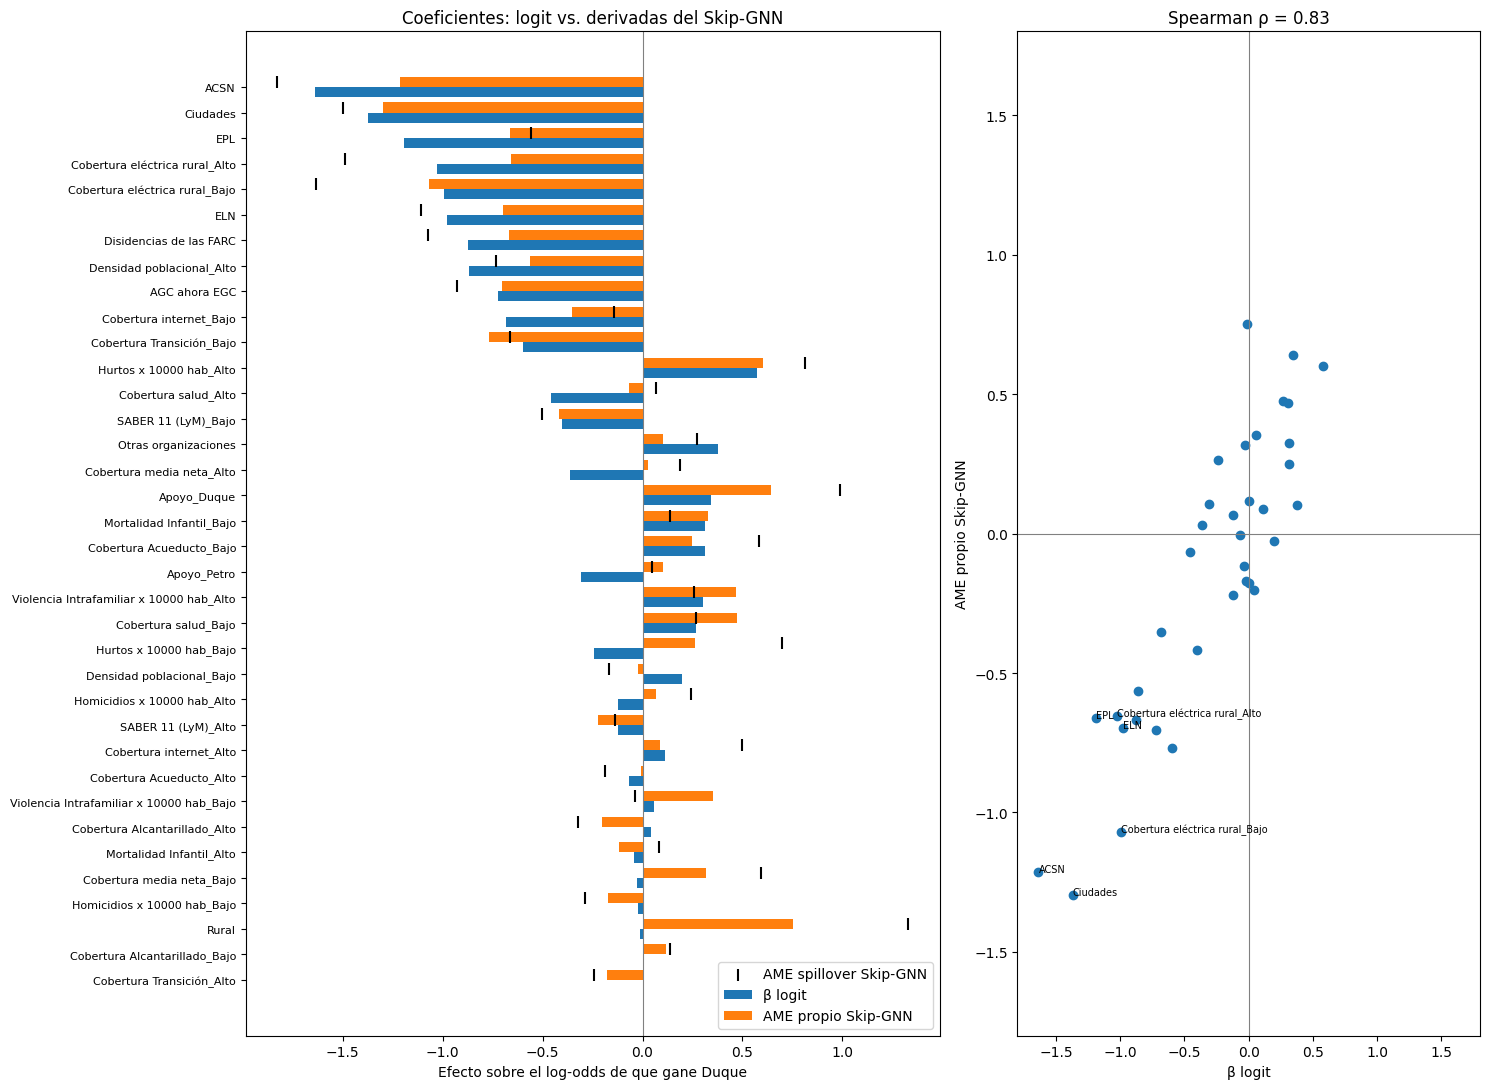

In [12]:
orden = tabla.reindex(tabla['beta_logit'].abs().sort_values().index)
fig, axes = plt.subplots(1, 2, figsize=(15, 11), gridspec_kw={'width_ratios': [3, 2]})

# Panel 1: comparación lado a lado
ypos = np.arange(len(orden))
axes[0].barh(ypos - 0.2, orden['beta_logit'], height=0.4, label='β logit')
axes[0].barh(ypos + 0.2, orden['AME_propio_skip'], height=0.4, label='AME propio Skip-GNN')
axes[0].scatter(orden['AME_spillover_skip'], ypos + 0.2, color='k', marker='|', s=80,
                label='AME spillover Skip-GNN', zorder=3)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels(orden['variable'], fontsize=8)
axes[0].axvline(0, color='grey', lw=0.8)
axes[0].set_xlabel('Efecto sobre el log-odds de que gane Duque')
axes[0].set_title('Coeficientes: logit vs. derivadas del Skip-GNN')
axes[0].legend(loc='lower right')

# Panel 2: dispersión beta vs AME
axes[1].scatter(tabla['beta_logit'], tabla['AME_propio_skip'])
lim = np.abs(tabla[['beta_logit', 'AME_propio_skip']].values).max() * 1.1
axes[1].axhline(0, color='grey', lw=0.8); axes[1].axvline(0, color='grey', lw=0.8)
axes[1].set_xlim(-lim, lim); axes[1].set_ylim(-lim, lim)
axes[1].set_xlabel('β logit'); axes[1].set_ylabel('AME propio Skip-GNN')
axes[1].set_title(f'Spearman ρ = {rho:.2f}')
for _, r in tabla.loc[tabla['beta_logit'].abs().nlargest(6).index].iterrows():
    axes[1].annotate(r['variable'], (r['beta_logit'], r['AME_propio_skip']), fontsize=7)

plt.tight_layout()
plt.show()

### Heterogeneidad: el coeficiente local por municipio

En el logit cada variable tiene un único coeficiente. En el Skip-GNN cada municipio tiene el suyo. La caja muestra la distribución de $\partial \ell_i / \partial x_{ik}$ entre los 965 municipios, y el punto rojo es el $\beta_k$ del logit.

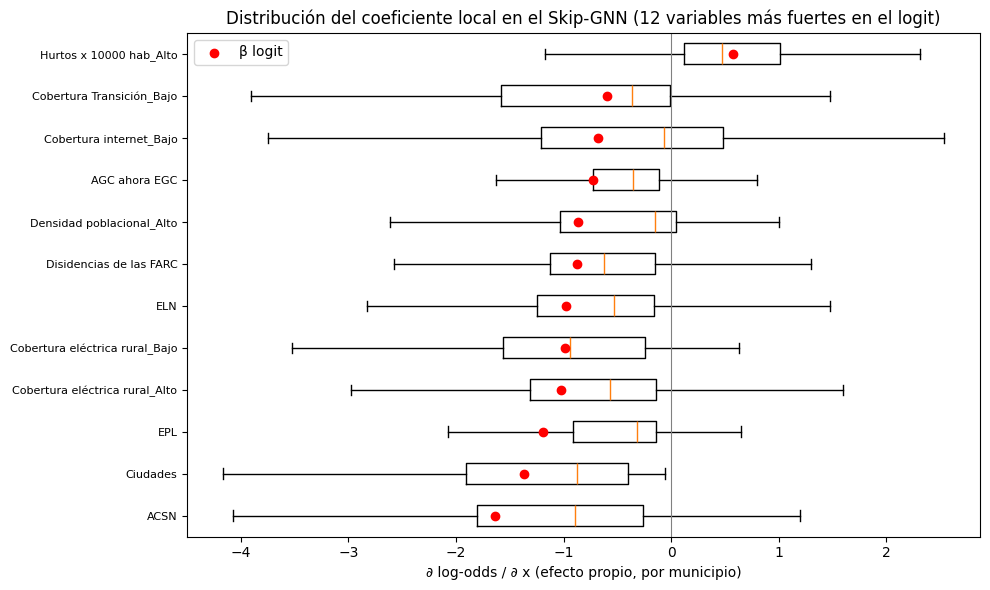

In [13]:
top = tabla['beta_logit'].abs().nlargest(12).index
fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot([propio[:, k] for k in top], vert=False, showfliers=False)
ax.scatter(tabla.loc[top, 'beta_logit'], np.arange(1, len(top) + 1), color='red', zorder=3, label='β logit')
ax.set_yticklabels([feature_cols[k] for k in top], fontsize=8)
ax.axvline(0, color='grey', lw=0.8)
ax.set_xlabel('∂ log-odds / ∂ x (efecto propio, por municipio)')
ax.set_title('Distribución del coeficiente local en el Skip-GNN (12 variables más fuertes en el logit)')
ax.legend()
plt.tight_layout()
plt.show()